# 🎬 Data Warehouse - IMDB Top 1000 Movies & TV Shows

**Mata Kuliah:** Data Warehouse & Business Intelligence  
**Dataset:** [IMDB Top 1000 Movies & TV Shows — Kaggle](https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows)  

---
## Alur Proyek
1. **Latar Belakang** - Tujuan & ruang lingkup
2. **Upload** - Load data dari Kaggle
3. **Transform** - Pembersihan & normalisasi data
4. **Load** - Membangun Data Warehouse (Star Schema dengan SQLite)
5. **Analisis Data** - Query & visualisasi insight love u mas yud <3

---
## 1. Latar Belakang

IMDB (Internet Movie Database) adalah basis data film dan serial TV terbesar di dunia. Dataset **Top 1000 Movies & TV Shows** memuat informasi komprehensif mengenai:
- Judul, tahun rilis, genre, sertifikat, durasi
- Rating IMDB dan Meta Score
- Sutradara, pemeran utama
- Jumlah votes dan pendapatan kotor (gross revenue)

**Tujuan Proyek:**
- Membangun **Data Warehouse** dengan skema **Star Schema**
- Melakukan proses **ETL** (Extract → Transform → Load)
- Menghasilkan **insight bisnis** melalui analisis data dan visualisasi

**Skema yang Digunakan:** Star Schema
- **Fact Table:** `fact_movie_performance` (rating, votes, gross, runtime)
- **Dimension Tables:** `dim_movie`, `dim_director`, `dim_genre`, `dim_time`, `dim_certificate`

---
## 2. Setup - Install & Import Library

In [ ]:
# Install dependencies
!pip install kaggle pandas numpy matplotlib seaborn sqlalchemy plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

---
## 3. UPLOAD - Upload Data dari Kaggle

In [ ]:
# Load CSV ke DataFrame
df_raw = pd.read_csv('imdb_top_1000.csv')

print(f'Shape dataset: {df_raw.shape}')
print(f'Kolom: {list(df_raw.columns)}')
print('\n Preview 3 baris pertama:')
df_raw.head(3)

Shape dataset: (1000, 16)
Kolom: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

 Preview 3 baris pertama:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [ ]:
# Eksplorasi awal
print('='*55)
print('INFO DATASET')
print('='*55)
df_raw.info()

print('\n' + '='*55)
print('MISSING VALUES PER KOLOM')
print('='*55)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print('\n' + '='*55)
print('STATISTIK DESKRIPTIF')
print('='*55)
df_raw.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB

MISSING VALUES PER KOLO

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


---
## 4. TRANSFORM - Pembersihan & Normalisasi Data

In [ ]:
# ── STEP 1: Copy DataFrame ──────────────────────────────────────────────────
df = df_raw.copy()
print(f'Dataset: {df.shape[0]} baris, {df.shape[1]} kolom')

Dataset: 1000 baris, 16 kolom


In [ ]:
# ── STEP 2: Bersihkan kolom Runtime ─────────────────────────────────────────
# Contoh: '142 min' → 142
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False).str.strip()
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')
df['Runtime'].fillna(df['Runtime'].median(), inplace=True)
df['Runtime'] = df['Runtime'].astype(int)

print(f'Runtime - min: {df.Runtime.min()} mnt, max: {df.Runtime.max()} mnt, median: {df.Runtime.median()} mnt')

Runtime — min: 45 mnt, max: 321 mnt, median: 119.0 mnt


In [ ]:
# ── STEP 3: Bersihkan kolom Gross ────────────────────────────────────────────
# Contoh: '28,341,469' → 28341469
df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

gross_median = df['Gross'].median()
df['Gross'].fillna(0, inplace=True)  # 0 = data tidak tersedia

print(f'Gross - missing diisi 0, median non-zero: ${gross_median:,.0f}')

Gross — missing diisi 0, median non-zero: $23,530,892


In [ ]:
# ── STEP 4: Bersihkan Released_Year ──────────────────────────────────────────
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'].fillna(df['Released_Year'].median(), inplace=True)
df['Released_Year'] = df['Released_Year'].astype(int)

print(f'Released_Year - range: {df.Released_Year.min()} - {df.Released_Year.max()}')

Released_Year — range: 1920 - 2020


In [ ]:
# ── STEP 5: Isi missing values lainnya ──────────────────────────────────────
df['Certificate'].fillna('Not Rated', inplace=True)
df['Meta_score'].fillna(df['Meta_score'].median(), inplace=True)
df['Meta_score'] = df['Meta_score'].astype(int)

print('Missing values diatasi:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'Tidak ada missing values tersisa {df.isnull().sum().sum()}')

Missing values diatasi:
Series([], dtype: int64)
Tidak ada missing values tersisa 0


In [ ]:
# ── STEP 6: Tambah kolom turunan ────────────────────────────────────────────
# Dekade
df['Decade'] = (df['Released_Year'] // 10 * 10).astype(str) + 's'

# Era film
def get_era(year):
    if year < 1960: return 'Classic (pre-1960)'
    elif year < 1980: return 'New Hollywood (1960-1979)'
    elif year < 2000: return 'Blockbuster Era (1980-1999)'
    elif year < 2010: return '2000s'
    else: return 'Modern (2010+)'

df['Era'] = df['Released_Year'].apply(get_era)

# Genre utama (ambil genre pertama)
df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()

# Rating kategori
def rating_category(r):
    if r >= 8.5: return 'Masterpiece (8.5+)'
    elif r >= 8.0: return 'Excellent (8.0-8.4)'
    elif r >= 7.5: return 'Very Good (7.5-7.9)'
    else: return 'Good (7.0-7.4)'

df['Rating_Category'] = df['IMDB_Rating'].apply(rating_category)

print('Kolom turunan berhasil ditambahkan:')
print(df[['Series_Title', 'Released_Year', 'Decade', 'Era', 'Primary_Genre', 'Rating_Category']].head(5))

Kolom turunan berhasil ditambahkan:
               Series_Title  Released_Year Decade  \
0  The Shawshank Redemption           1994  1990s   
1             The Godfather           1972  1970s   
2           The Dark Knight           2008  2000s   
3    The Godfather: Part II           1974  1970s   
4              12 Angry Men           1957  1950s   

                           Era Primary_Genre     Rating_Category  
0  Blockbuster Era (1980-1999)         Drama  Masterpiece (8.5+)  
1    New Hollywood (1960-1979)         Crime  Masterpiece (8.5+)  
2                        2000s        Action  Masterpiece (8.5+)  
3    New Hollywood (1960-1979)         Crime  Masterpiece (8.5+)  
4           Classic (pre-1960)         Crime  Masterpiece (8.5+)  


In [ ]:
# ── STEP 7: Hapus duplikat ──────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['Series_Title'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
df['movie_id'] = df.index + 1

print(f'Duplikat dihapus: {before - len(df)} baris')
print(f'Total data setelah transform: {len(df)} baris')

Duplikat dihapus: 1 baris
Total data setelah transform: 999 baris


In [ ]:
# ── STEP 8: Ringkasan hasil Transform ───────────────────────────────────────
print('='*55)
print('RINGKASAN HASIL TRANSFORM')
print('='*55)
print(f'  Total record       : {len(df)}')
print(f'  Total kolom        : {len(df.columns)}')
print(f'  Missing values     : {df.isnull().sum().sum()}')
print(f'  Tahun rilis        : {df.Released_Year.min()} – {df.Released_Year.max()}')
print(f'  Rating IMDB        : {df.IMDB_Rating.min()} – {df.IMDB_Rating.max()}')
print(f'  Genre unik (utama) : {df.Primary_Genre.nunique()}')
print(f'  Sutradara unik     : {df.Director.nunique()}')
print('='*55)
df.head(3)

RINGKASAN HASIL TRANSFORM
  Total record       : 999
  Total kolom        : 21
  Missing values     : 0
  Tahun rilis        : 1920 – 2020
  Rating IMDB        : 7.6 – 9.3
  Genre unik (utama) : 14
  Sutradara unik     : 547


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,...,Star2,Star3,Star4,No_of_Votes,Gross,Decade,Era,Primary_Genre,Rating_Category,movie_id
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142,Drama,9.3,Two imprisoned men bond over a number of years...,80,Frank Darabont,...,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,1990s,Blockbuster Era (1980-1999),Drama,Masterpiece (8.5+),1
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100,Francis Ford Coppola,...,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,1970s,New Hollywood (1960-1979),Crime,Masterpiece (8.5+),2
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84,Christopher Nolan,...,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,2000s,2000s,Action,Masterpiece (8.5+),3


---
## 5. LOAD - Membangun Data Warehouse (Star Schema)

Database: **SQLite** (in-memory, cocok untuk prototyping)

```
                ┌──────────────┐
                │  dim_time    │
                └──────┬───────┘
  ┌─────────────┐      │      ┌──────────────┐
  │  dim_genre  ├──────┤      │ dim_director │
  └─────────────┘      │      └──────────────┘
                        ▼
               ┌────────────────────┐
               │ fact_movie_perf... │
               └────────────────────┘
                        │
  ┌─────────────┐       │      ┌──────────────────┐
  │  dim_movie  ├───────┘      │ dim_certificate  │
  └─────────────┘              └──────────────────┘
```

In [ ]:
# ── Buat koneksi SQLite ──────────────────────────────────────────────────────
conn = sqlite3.connect('imdb_datawarehouse.db')
cursor = conn.cursor()

# Drop tables jika sudah ada (untuk re-run)
tables = ['fact_movie_performance', 'dim_movie', 'dim_director',
          'dim_genre', 'dim_time', 'dim_certificate']
for t in tables:
    cursor.execute(f'DROP TABLE IF EXISTS {t}')
conn.commit()
print('Koneksi SQLite berhasil dibuat: imdb_datawarehouse.db')

Koneksi SQLite berhasil dibuat: imdb_datawarehouse.db


In [ ]:
# ── dim_time ─────────────────────────────────────────────────────────────────
dim_time = df[['Released_Year', 'Decade', 'Era']].drop_duplicates().reset_index(drop=True)
dim_time.insert(0, 'time_id', range(1, len(dim_time) + 1))
dim_time.columns = ['time_id', 'released_year', 'decade', 'era']
dim_time.to_sql('dim_time', conn, if_exists='replace', index=False)
print(f'✅ dim_time          → {len(dim_time)} baris')

# ── dim_director ──────────────────────────────────────────────────────────────
dir_stats = df.groupby('Director').agg(
    total_movies=('movie_id', 'count'),
    avg_rating=('IMDB_Rating', 'mean'),
    total_gross=('Gross', 'sum')
).reset_index()
dim_director = dir_stats.copy()
dim_director.insert(0, 'director_id', range(1, len(dim_director) + 1))
dim_director.columns = ['director_id', 'director_name', 'total_movies', 'avg_rating', 'total_gross']
dim_director['avg_rating'] = dim_director['avg_rating'].round(2)
dim_director.to_sql('dim_director', conn, if_exists='replace', index=False)
print(f'✅ dim_director      → {len(dim_director)} baris')

# ── dim_genre ─────────────────────────────────────────────────────────────────
genres = df['Primary_Genre'].unique()
dim_genre = pd.DataFrame({'genre_id': range(1, len(genres)+1), 'genre_name': sorted(genres)})
dim_genre.to_sql('dim_genre', conn, if_exists='replace', index=False)
print(f'✅ dim_genre         → {len(dim_genre)} baris')

# ── dim_certificate ───────────────────────────────────────────────────────────
certs = df['Certificate'].unique()
dim_certificate = pd.DataFrame({'cert_id': range(1, len(certs)+1), 'certificate': sorted(certs)})
dim_certificate.to_sql('dim_certificate', conn, if_exists='replace', index=False)
print(f'✅ dim_certificate   → {len(dim_certificate)} baris')

# ── dim_movie ─────────────────────────────────────────────────────────────────
dim_movie = df[['movie_id', 'Series_Title', 'Overview', 'Star1', 'Star2', 'Star3', 'Star4']].copy()
dim_movie.columns = ['movie_id', 'title', 'overview', 'star1', 'star2', 'star3', 'star4']
dim_movie.to_sql('dim_movie', conn, if_exists='replace', index=False)
print(f'✅ dim_movie         → {len(dim_movie)} baris')

✅ dim_time          → 99 baris
✅ dim_director      → 547 baris
✅ dim_genre         → 14 baris
✅ dim_certificate   → 17 baris
✅ dim_movie         → 999 baris


In [ ]:
# ── fact_movie_performance ────────────────────────────────────────────────────
# Gabungkan semua foreign key
df_fact = df.merge(dim_time, left_on='Released_Year', right_on='released_year', how='left')
df_fact = df_fact.merge(dim_director, left_on='Director', right_on='director_name', how='left')
df_fact = df_fact.merge(dim_genre, left_on='Primary_Genre', right_on='genre_name', how='left')
df_fact = df_fact.merge(dim_certificate, left_on='Certificate', right_on='certificate', how='left')

fact = df_fact[[
    'movie_id', 'director_id', 'time_id', 'genre_id', 'cert_id',
    'IMDB_Rating', 'Meta_score', 'Runtime', 'No_of_Votes', 'Gross'
]].copy()
fact.columns = [
    'movie_id', 'director_id', 'time_id', 'genre_id', 'cert_id',
    'imdb_rating', 'meta_score', 'runtime_minutes', 'no_of_votes', 'gross_revenue'
]

fact.to_sql('fact_movie_performance', conn, if_exists='replace', index=False)
print(f'fact_movie_performance → {len(fact)} baris')

print('\n' + '='*55)
print('DATA WAREHOUSE BERHASIL DIBANGUN!')
print('='*55)
for t in tables:
    count = cursor.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:<30}: {count:>5} baris')

fact_movie_performance → 999 baris

DATA WAREHOUSE BERHASIL DIBANGUN!
  fact_movie_performance        :   999 baris
  dim_movie                     :   999 baris
  dim_director                  :   547 baris
  dim_genre                     :    14 baris
  dim_time                      :    99 baris
  dim_certificate               :    17 baris


In [ ]:
# ── Verifikasi: Cek schema tabel fakta ───────────────────────────────────────
print('📋 Schema fact_movie_performance:')
schema = cursor.execute('PRAGMA table_info(fact_movie_performance)').fetchall()
schema_df = pd.DataFrame(schema, columns=['cid','name','type','notnull','default','pk'])
print(schema_df[['name','type']].to_string(index=False))

📋 Schema fact_movie_performance:
           name    type
       movie_id INTEGER
    director_id INTEGER
        time_id INTEGER
       genre_id INTEGER
        cert_id INTEGER
    imdb_rating    REAL
     meta_score INTEGER
runtime_minutes INTEGER
    no_of_votes INTEGER
  gross_revenue    REAL


---
## 6. ANALISIS DATA

Semua query dijalankan langsung terhadap Data Warehouse (SQLite).

In [ ]:
# ── Query Helper ─────────────────────────────────────────────────────────────
def query(sql):
    return pd.read_sql_query(sql, conn)

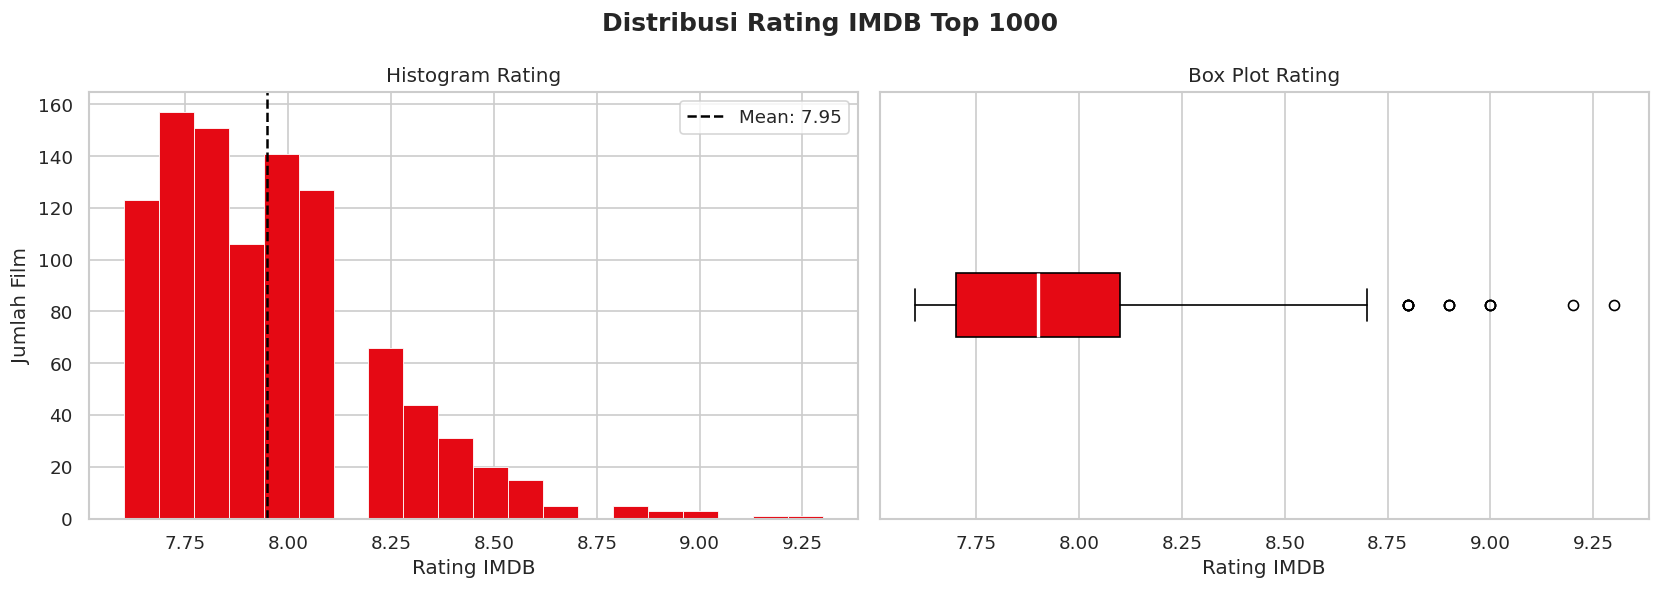

Statistik Rating IMDB:
count    999.000
mean       7.949
std        0.276
min        7.600
25%        7.700
50%        7.900
75%        8.100
max        9.300
Name: imdb_rating, dtype: float64


In [ ]:
# ── A1. Distribusi Rating IMDB ───────────────────────────────────────────────
df_rating = query('SELECT imdb_rating FROM fact_movie_performance')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Rating IMDB Top 1000', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df_rating['imdb_rating'], bins=20, color='#E50914', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Rating IMDB')
axes[0].set_ylabel('Jumlah Film')
axes[0].set_title('Histogram Rating')
axes[0].axvline(df_rating['imdb_rating'].mean(), color='black', linestyle='--', label=f'Mean: {df_rating["imdb_rating"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_rating['imdb_rating'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#E50914', color='black'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_xlabel('Rating IMDB')
axes[1].set_title('Box Plot Rating')
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('plot_rating_distribution.png', bbox_inches='tight')
plt.show()

print('Statistik Rating IMDB:')
print(df_rating['imdb_rating'].describe().round(3))

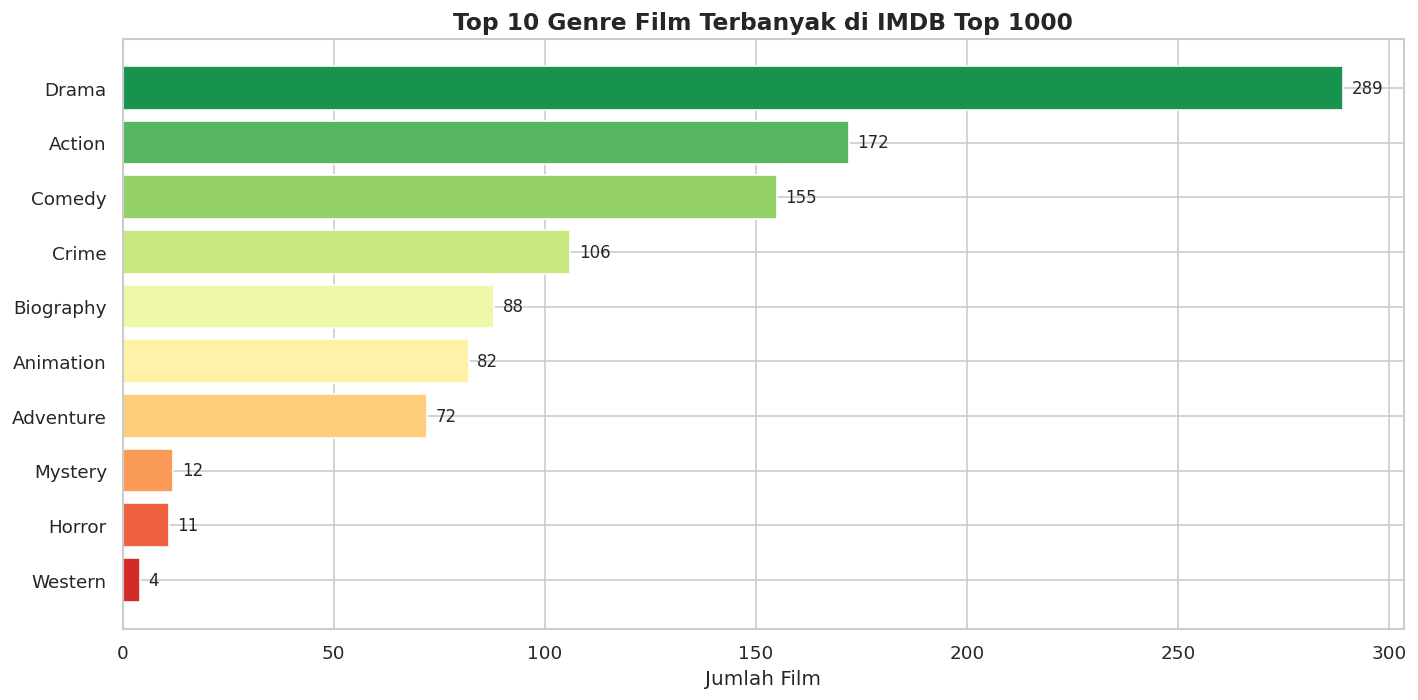

Data Query:
genre_name  total_film  avg_rating
     Drama         289        7.96
    Action         172        7.95
    Comedy         155        7.90
     Crime         106        8.02
 Biography          88        7.94
 Animation          82        7.93
 Adventure          72        7.94
   Mystery          12        7.98
    Horror          11        7.91
   Western           4        8.35


In [ ]:
# ── A2. Top 10 Genre Terbanyak ───────────────────────────────────────────────
sql = '''
    SELECT g.genre_name, COUNT(*) AS total_film,
           ROUND(AVG(f.imdb_rating), 2) AS avg_rating
    FROM fact_movie_performance f
    JOIN dim_genre g ON f.genre_id = g.genre_id
    GROUP BY g.genre_name
    ORDER BY total_film DESC
    LIMIT 10
'''
df_genre = query(sql)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_genre['genre_name'][::-1], df_genre['total_film'][::-1],
               color=sns.color_palette('RdYlGn', 10))
ax.set_xlabel('Jumlah Film')
ax.set_title('Top 10 Genre Film Terbanyak di IMDB Top 1000', fontsize=14, fontweight='bold')

for bar, val in zip(bars, df_genre['total_film'][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot_genre_count.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_genre.to_string(index=False))

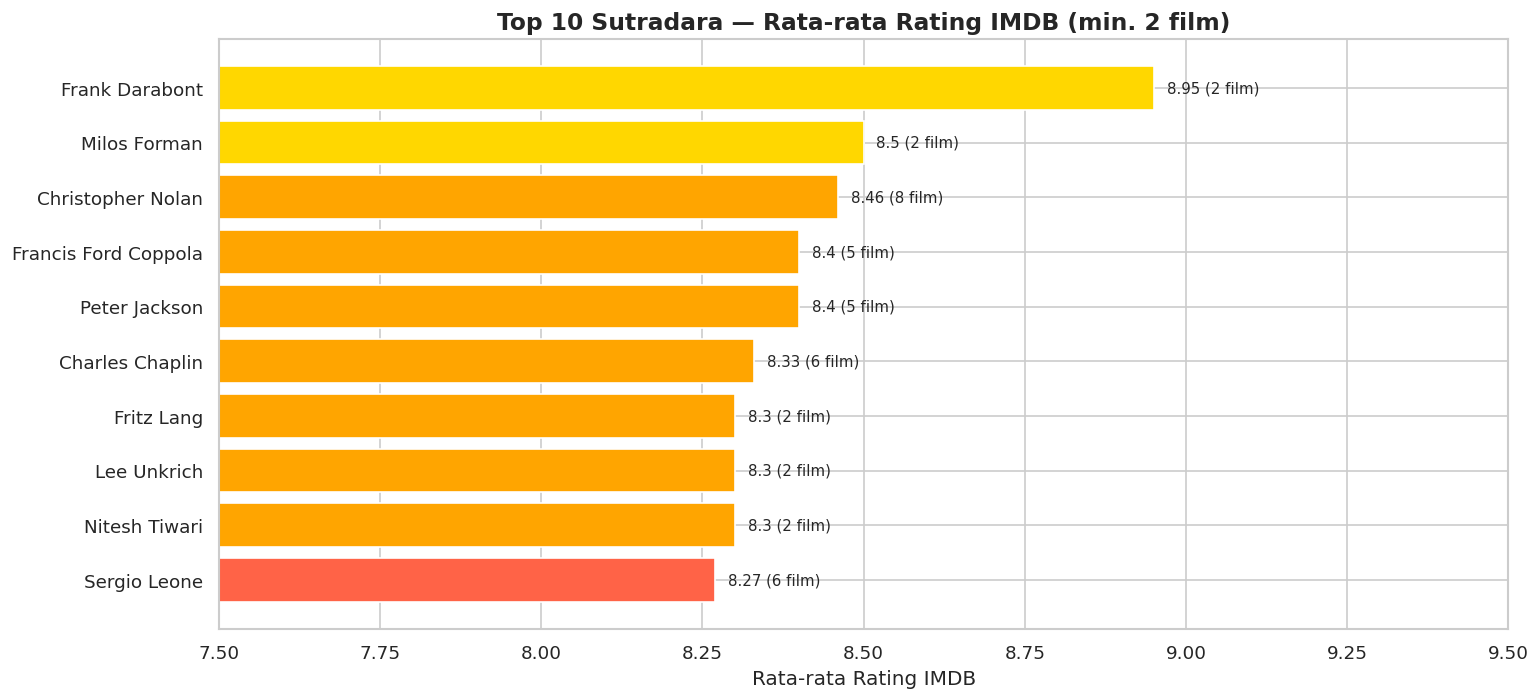

Data Query:
       director_name  total_movies  avg_rating  total_gross_M
      Frank Darabont             2        8.95          165.1
        Milos Forman             2        8.50          164.0
   Christopher Nolan             8        8.46         1937.5
Francis Ford Coppola             5        8.40          346.8
       Peter Jackson             5        8.40         1597.3
     Charles Chaplin             6        8.33           11.4
          Fritz Lang             2        8.30            1.3
         Lee Unkrich             2        8.30          624.7
       Nitesh Tiwari             2        8.30           13.3
        Sergio Leone             6        8.27           46.9


In [ ]:
# ── A3. Top 10 Sutradara berdasarkan Rata-rata Rating ────────────────────────
sql = '''
    SELECT d.director_name, d.total_movies,
           ROUND(d.avg_rating, 2) AS avg_rating,
           ROUND(d.total_gross / 1000000.0, 1) AS total_gross_M
    FROM dim_director d
    WHERE d.total_movies >= 2
    ORDER BY d.avg_rating DESC
    LIMIT 10
'''
df_dir = query(sql)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#FFD700' if r >= 8.5 else '#FFA500' if r >= 8.3 else '#FF6347'
          for r in df_dir['avg_rating']]
bars = ax.barh(df_dir['director_name'][::-1], df_dir['avg_rating'][::-1], color=colors[::-1])
ax.set_xlabel('Rata-rata Rating IMDB')
ax.set_title('Top 10 Sutradara — Rata-rata Rating IMDB (min. 2 film)', fontsize=14, fontweight='bold')
ax.set_xlim(7.5, 9.5)

for bar, row in zip(bars, df_dir.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{row.avg_rating} ({row.total_movies} film)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_top_directors.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_dir.to_string(index=False))

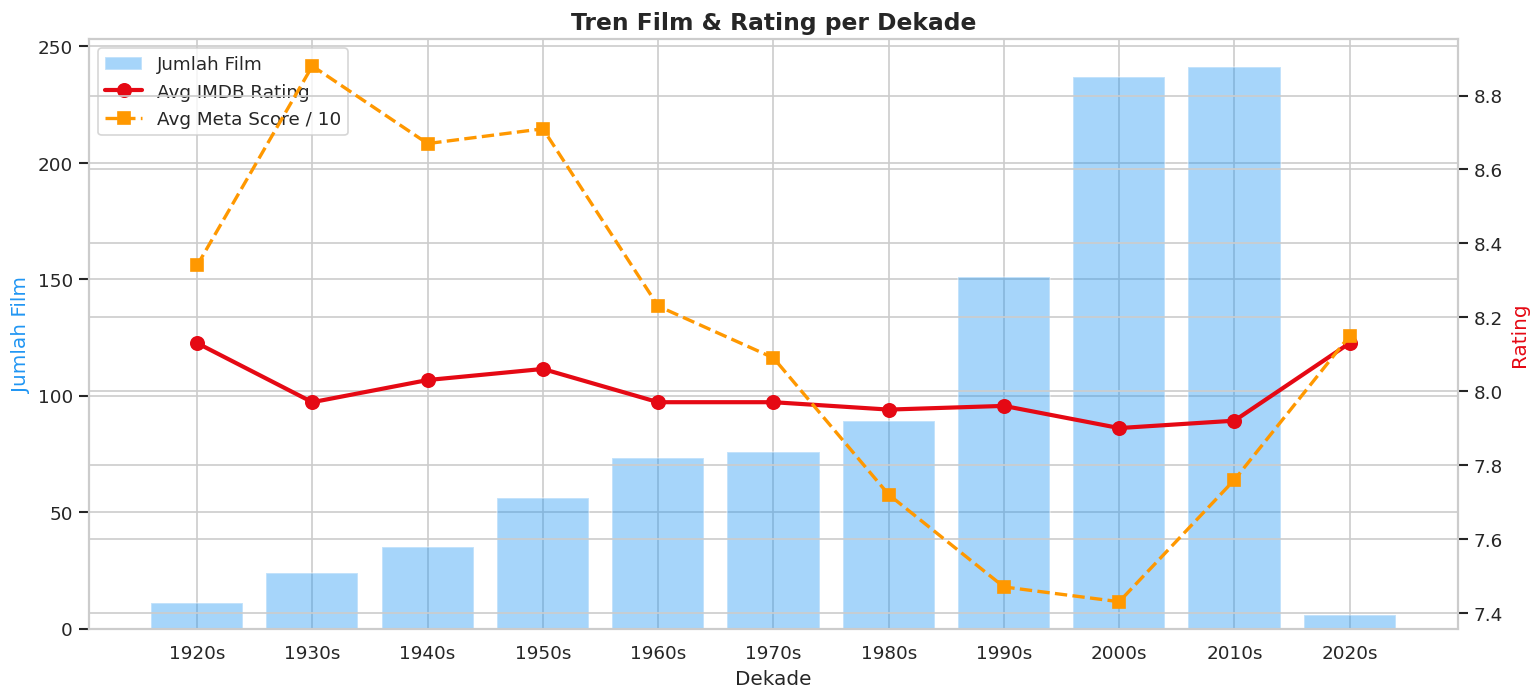

Data Query:
decade  total_film  avg_rating  avg_meta
 1920s          11        8.13      83.4
 1930s          24        7.97      88.8
 1940s          35        8.03      86.7
 1950s          56        8.06      87.1
 1960s          73        7.97      82.3
 1970s          76        7.97      80.9
 1980s          89        7.95      77.2
 1990s         151        7.96      74.7
 2000s         237        7.90      74.3
 2010s         241        7.92      77.6
 2020s           6        8.13      81.5


In [ ]:
# ── A4. Tren Rating IMDB per Dekade ──────────────────────────────────────────
sql = '''
    SELECT t.decade,
           COUNT(*) AS total_film,
           ROUND(AVG(f.imdb_rating), 2) AS avg_rating,
           ROUND(AVG(f.meta_score), 1) AS avg_meta
    FROM fact_movie_performance f
    JOIN dim_time t ON f.time_id = t.time_id
    GROUP BY t.decade
    ORDER BY t.decade
'''
df_decade = query(sql)

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.bar(df_decade['decade'], df_decade['total_film'], color='#2196F3', alpha=0.4, label='Jumlah Film')
ax2.plot(df_decade['decade'], df_decade['avg_rating'], 'o-', color='#E50914', linewidth=2.5,
         markersize=8, label='Avg IMDB Rating')
ax2.plot(df_decade['decade'], df_decade['avg_meta']/10, 's--', color='#FF9800', linewidth=2,
         markersize=7, label='Avg Meta Score / 10')

ax1.set_xlabel('Dekade')
ax1.set_ylabel('Jumlah Film', color='#2196F3')
ax2.set_ylabel('Rating', color='#E50914')
ax1.set_title('Tren Film & Rating per Dekade', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_trend_decade.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_decade.to_string(index=False))

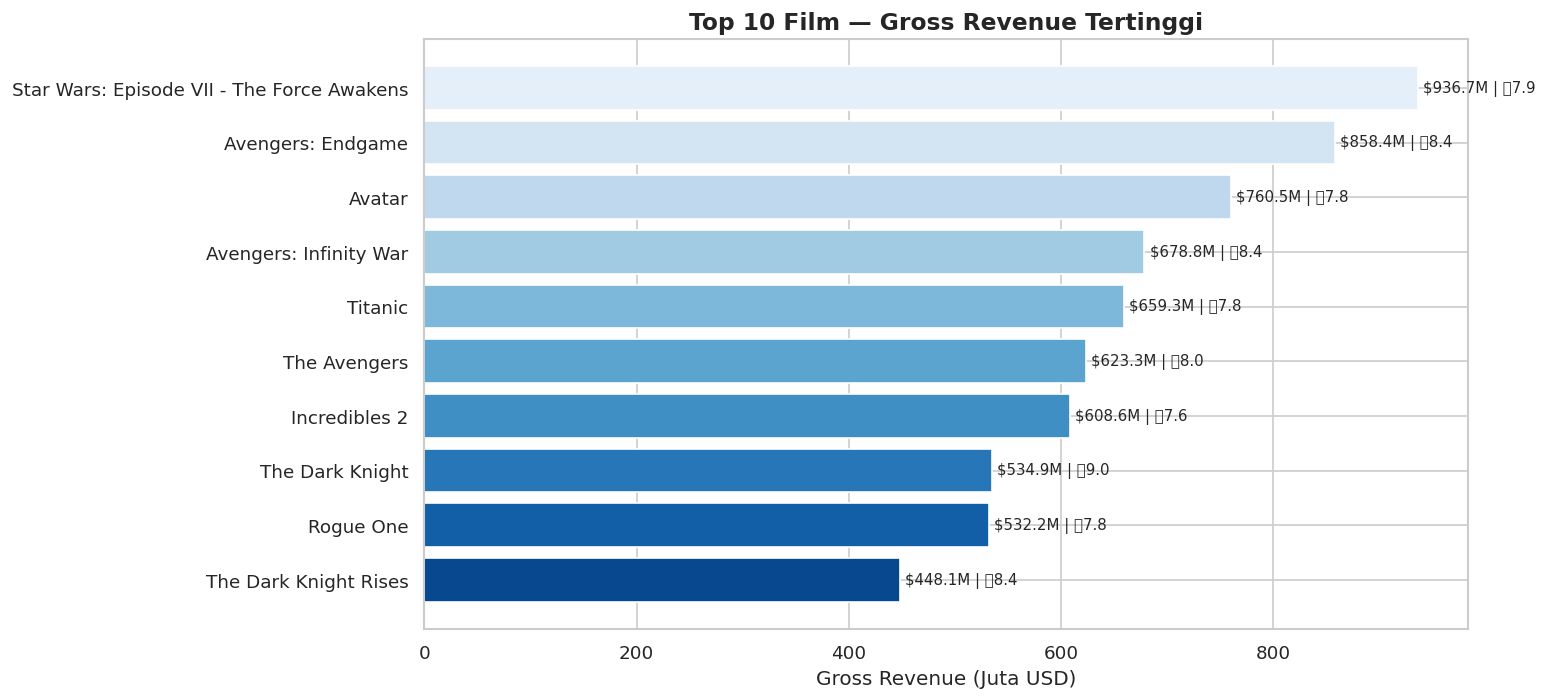

Data Query:
                                     title  released_year genre_name  gross_M  imdb_rating
Star Wars: Episode VII - The Force Awakens           2015     Action    936.7          7.9
                         Avengers: Endgame           2019     Action    858.4          8.4
                                    Avatar           2009     Action    760.5          7.8
                    Avengers: Infinity War           2018     Action    678.8          8.4
                                   Titanic           1997      Drama    659.3          7.8
                              The Avengers           2012     Action    623.3          8.0
                             Incredibles 2           2018  Animation    608.6          7.6
                           The Dark Knight           2008     Action    534.9          9.0
                                 Rogue One           2016     Action    532.2          7.8
                     The Dark Knight Rises           2012     Action    448.1 

In [ ]:
# ── A5. Top 10 Film berdasarkan Gross Revenue ─────────────────────────────────
sql = '''
    SELECT m.title, t.released_year, g.genre_name,
           ROUND(f.gross_revenue / 1000000.0, 1) AS gross_M,
           f.imdb_rating
    FROM fact_movie_performance f
    JOIN dim_movie m ON f.movie_id = m.movie_id
    JOIN dim_time t ON f.time_id = t.time_id
    JOIN dim_genre g ON f.genre_id = g.genre_id
    WHERE f.gross_revenue > 0
    ORDER BY f.gross_revenue DESC
    LIMIT 10
'''
df_gross = query(sql)

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('Blues_r', len(df_gross))
bars = ax.barh(df_gross['title'][::-1], df_gross['gross_M'][::-1], color=palette)
ax.set_xlabel('Gross Revenue (Juta USD)')
ax.set_title('Top 10 Film — Gross Revenue Tertinggi', fontsize=14, fontweight='bold')

for bar, row in zip(bars, df_gross.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${row.gross_M}M | ⭐{row.imdb_rating}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_top_gross.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_gross.to_string(index=False))

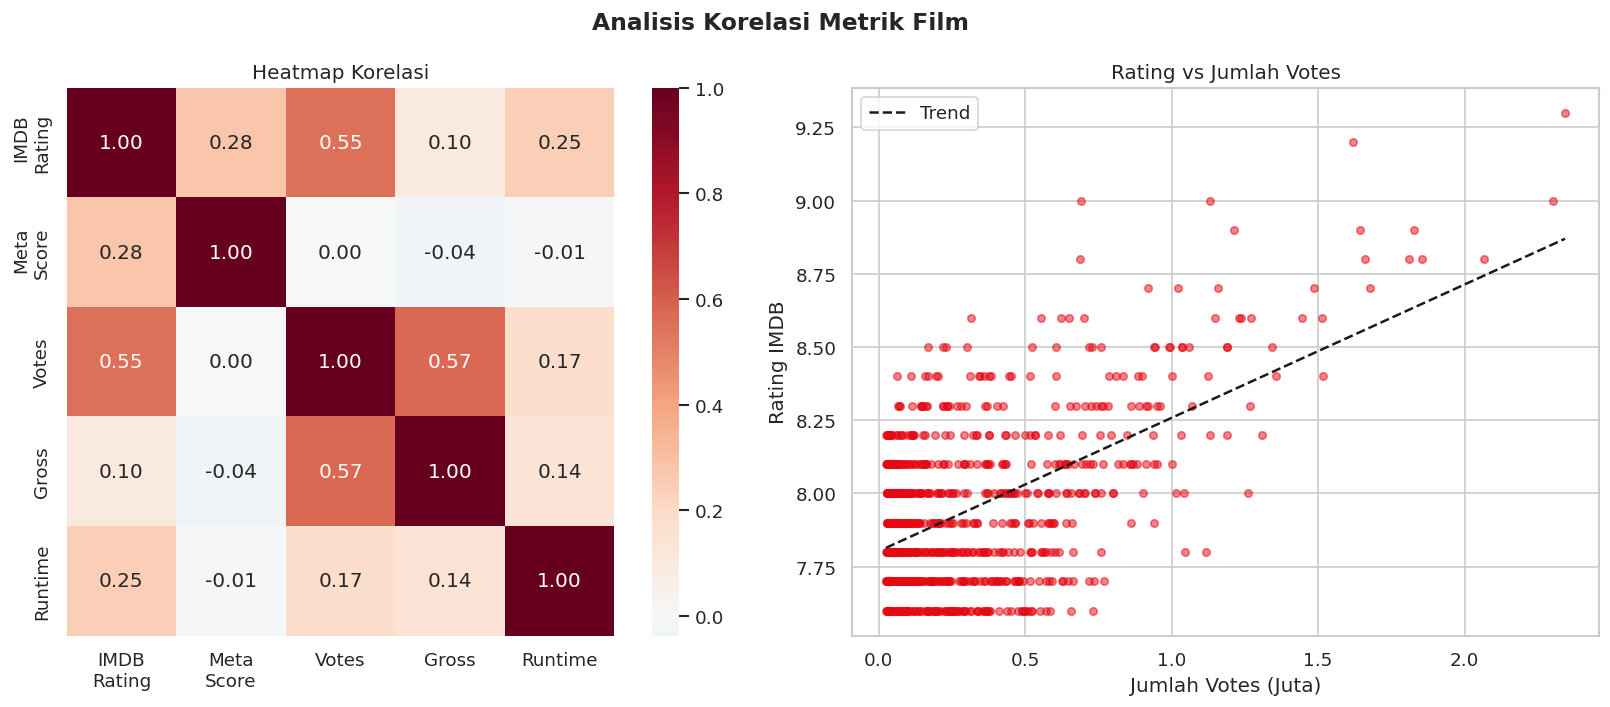

In [ ]:
# ── A6. Korelasi: Rating vs Gross Revenue vs Votes ────────────────────────────
sql = '''
    SELECT f.imdb_rating, f.meta_score, f.no_of_votes,
           f.gross_revenue, f.runtime_minutes, g.genre_name
    FROM fact_movie_performance f
    JOIN dim_genre g ON f.genre_id = g.genre_id
    WHERE f.gross_revenue > 0
'''
df_corr = query(sql)

# Heatmap korelasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Korelasi Metrik Film', fontsize=14, fontweight='bold')

numeric_cols = ['imdb_rating', 'meta_score', 'no_of_votes', 'gross_revenue', 'runtime_minutes']
corr_matrix = df_corr[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True,
            xticklabels=['IMDB\nRating','Meta\nScore','Votes','Gross','Runtime'],
            yticklabels=['IMDB\nRating','Meta\nScore','Votes','Gross','Runtime'])
axes[0].set_title('Heatmap Korelasi')

# Scatter: Rating vs Votes
axes[1].scatter(df_corr['no_of_votes']/1e6, df_corr['imdb_rating'],
                alpha=0.5, color='#E50914', s=20)
axes[1].set_xlabel('Jumlah Votes (Juta)')
axes[1].set_ylabel('Rating IMDB')
axes[1].set_title('Rating vs Jumlah Votes')

# Trend line
z = np.polyfit(df_corr['no_of_votes'], df_corr['imdb_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_corr['no_of_votes'].min(), df_corr['no_of_votes'].max(), 100)
axes[1].plot(x_line/1e6, p(x_line), 'k--', linewidth=1.5, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()

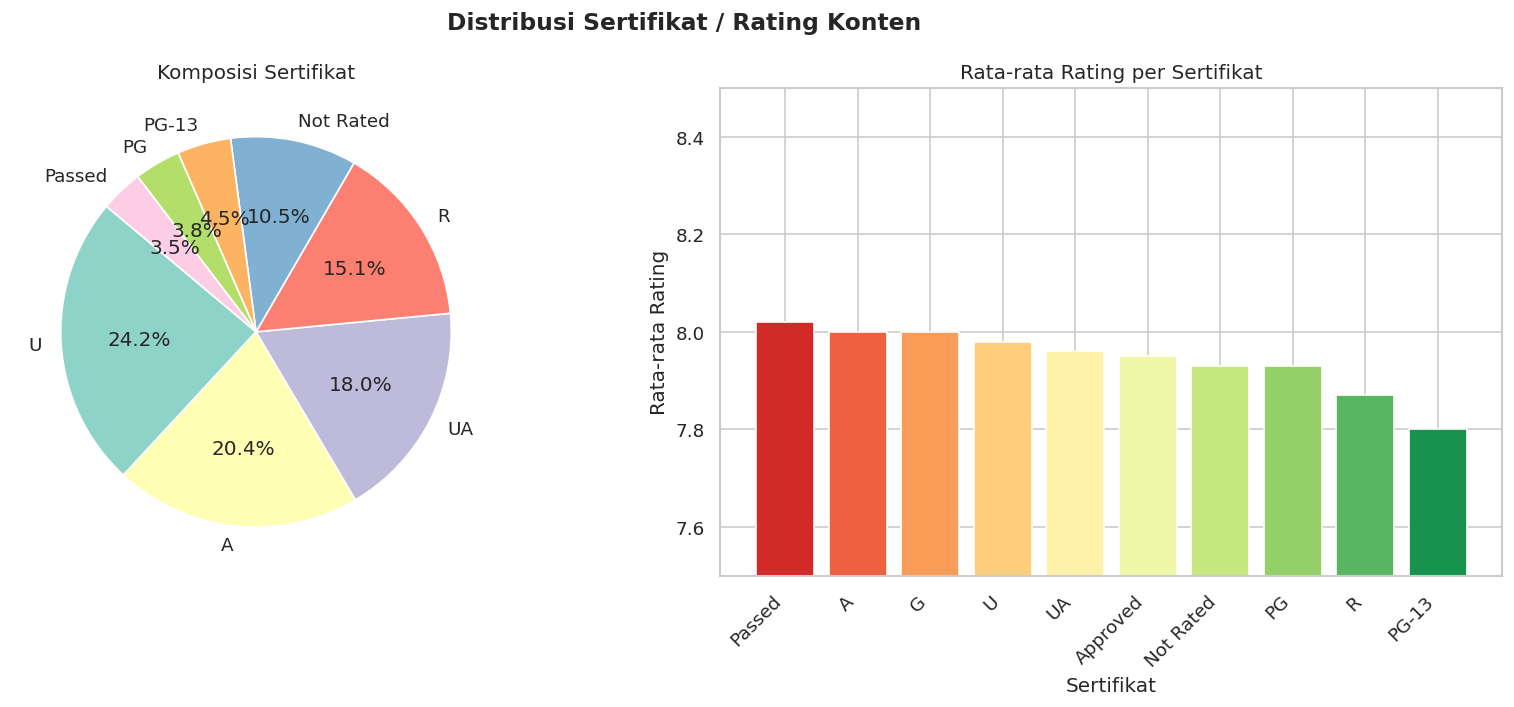

Data Query:
certificate  total  avg_rating
          U    234        7.98
          A    197        8.00
         UA    174        7.96
          R    146        7.87
  Not Rated    101        7.93
      PG-13     43        7.80
         PG     37        7.93
     Passed     34        8.02
          G     12        8.00
   Approved     11        7.95
      TV-PG      3        7.90
         GP      2        7.85
    Unrated      1        8.10
        U/A      1        7.60
      TV-MA      1        8.10
      TV-14      1        8.30
         16      1        8.10


In [ ]:
# ── A7. Distribusi Sertifikat / Rating Konten ────────────────────────────────
sql = '''
    SELECT c.certificate, COUNT(*) AS total,
           ROUND(AVG(f.imdb_rating), 2) AS avg_rating
    FROM fact_movie_performance f
    JOIN dim_certificate c ON f.cert_id = c.cert_id
    GROUP BY c.certificate
    ORDER BY total DESC
'''
df_cert = query(sql)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Sertifikat / Rating Konten', fontsize=14, fontweight='bold')

# Pie chart
top_certs = df_cert.head(8)
axes[0].pie(top_certs['total'], labels=top_certs['certificate'],
            autopct='%1.1f%%', colors=sns.color_palette('Set3', len(top_certs)),
            startangle=140)
axes[0].set_title('Komposisi Sertifikat')

# Bar: avg rating per cert
df_cert_sorted = df_cert[df_cert['total'] >= 5].sort_values('avg_rating', ascending=False)
axes[1].bar(df_cert_sorted['certificate'], df_cert_sorted['avg_rating'],
            color=sns.color_palette('RdYlGn', len(df_cert_sorted)))
axes[1].set_xlabel('Sertifikat')
axes[1].set_ylabel('Rata-rata Rating')
axes[1].set_title('Rata-rata Rating per Sertifikat')
axes[1].set_ylim(7.5, 8.5)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('plot_certificate.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_cert.to_string(index=False))

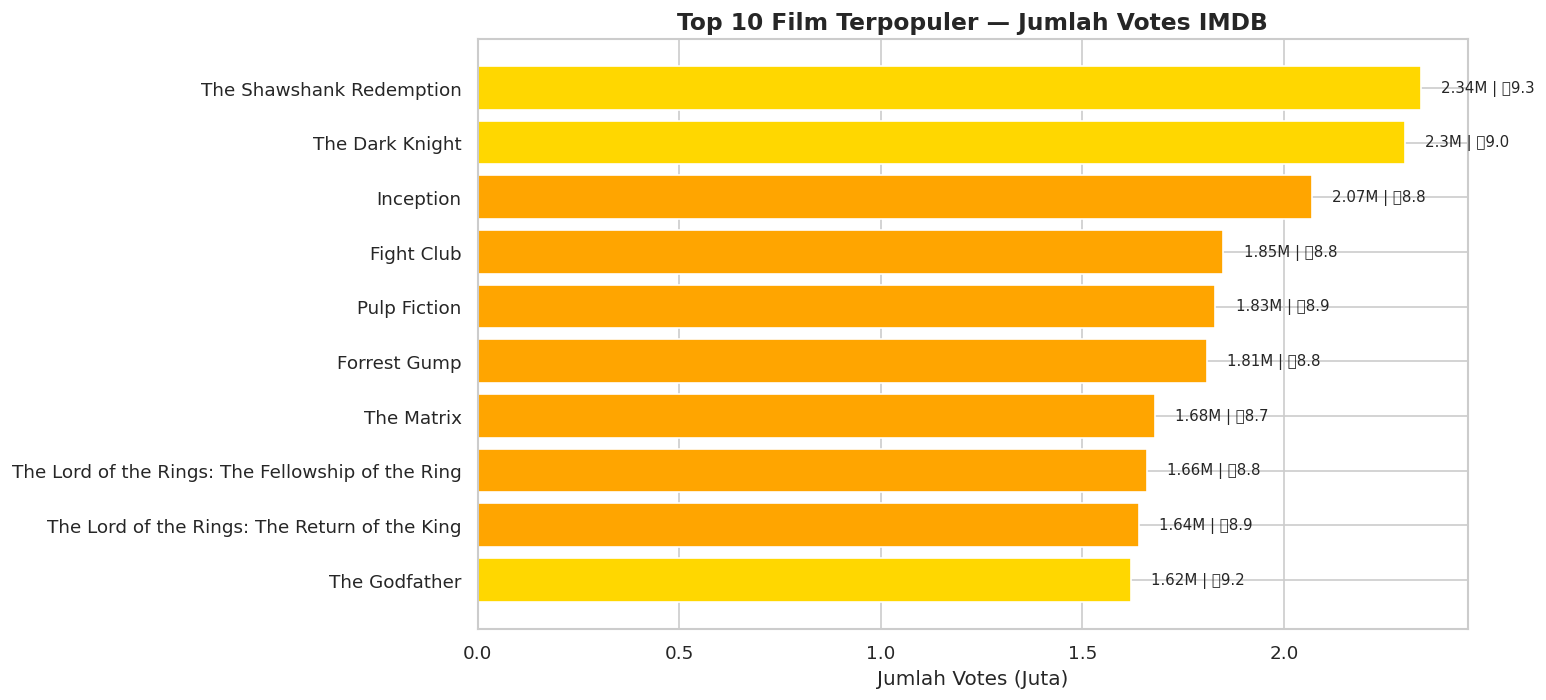

Data Query:
                                            title  released_year  imdb_rating  votes_M genre_name
                         The Shawshank Redemption           1994          9.3     2.34      Drama
                                  The Dark Knight           2008          9.0     2.30     Action
                                        Inception           2010          8.8     2.07     Action
                                       Fight Club           1999          8.8     1.85      Drama
                                     Pulp Fiction           1994          8.9     1.83      Crime
                                     Forrest Gump           1994          8.8     1.81      Drama
                                       The Matrix           1999          8.7     1.68     Action
The Lord of the Rings: The Fellowship of the Ring           2001          8.8     1.66     Action
    The Lord of the Rings: The Return of the King           2003          8.9     1.64     Action
        

In [ ]:
# ── A8. Top 10 Film Terpopuler (berdasarkan Votes) ────────────────────────────
sql = '''
    SELECT m.title, t.released_year, f.imdb_rating,
           ROUND(f.no_of_votes / 1000000.0, 2) AS votes_M,
           g.genre_name
    FROM fact_movie_performance f
    JOIN dim_movie m ON f.movie_id = m.movie_id
    JOIN dim_time t ON f.time_id = t.time_id
    JOIN dim_genre g ON f.genre_id = g.genre_id
    ORDER BY f.no_of_votes DESC
    LIMIT 10
'''
df_pop = query(sql)

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#FFD700' if r >= 9.0 else '#FFA500' if r >= 8.5 else '#FF6347'
          for r in df_pop['imdb_rating']]
bars = ax.barh(df_pop['title'][::-1], df_pop['votes_M'][::-1], color=colors[::-1])
ax.set_xlabel('Jumlah Votes (Juta)')
ax.set_title('Top 10 Film Terpopuler — Jumlah Votes IMDB', fontsize=14, fontweight='bold')

for bar, row in zip(bars, df_pop.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{row.votes_M}M | ⭐{row.imdb_rating}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_top_popular.png', bbox_inches='tight')
plt.show()

print('Data Query:')
print(df_pop.to_string(index=False))

---
## 7. Kesimpulan & Insight

Berdasarkan hasil analisis Data Warehouse IMDB Top 1000:

In [ ]:
# ── Ringkasan insight otomatis ────────────────────────────────────────────────
top_genre = query('''
    SELECT g.genre_name, COUNT(*) as c FROM fact_movie_performance f
    JOIN dim_genre g ON f.genre_id=g.genre_id GROUP BY g.genre_name ORDER BY c DESC LIMIT 1
''').iloc[0]

top_dir = query('''
    SELECT director_name, avg_rating FROM dim_director
    WHERE total_movies >= 2 ORDER BY avg_rating DESC LIMIT 1
''').iloc[0]

top_gross = query('''
    SELECT m.title, f.gross_revenue FROM fact_movie_performance f
    JOIN dim_movie m ON f.movie_id=m.movie_id
    ORDER BY f.gross_revenue DESC LIMIT 1
''').iloc[0]

top_movie = query('''
    SELECT m.title, f.imdb_rating FROM fact_movie_performance f
    JOIN dim_movie m ON f.movie_id=m.movie_id
    ORDER BY f.imdb_rating DESC LIMIT 1
''').iloc[0]

best_decade = query('''
    SELECT t.decade, ROUND(AVG(f.imdb_rating),2) avg_r FROM fact_movie_performance f
    JOIN dim_time t ON f.time_id=t.time_id GROUP BY t.decade ORDER BY avg_r DESC LIMIT 1
''').iloc[0]

print('='*60)
print('🎬 INSIGHT UTAMA DATA WAREHOUSE IMDB TOP 1000')
print('='*60)
print(f'  🏆 Film rating tertinggi : {top_movie["title"]} (⭐{top_movie["imdb_rating"]})')
print(f'  🎭 Genre terbanyak       : {top_genre["genre_name"]} ({top_genre["c"]} film)')
print(f'  🎬 Sutradara terbaik     : {top_dir["director_name"]} (avg ⭐{top_dir["avg_rating"]})')
print(f'  💰 Film pendapatan ting. : {top_gross["title"]} (${top_gross["gross_revenue"]/1e6:.0f}M)')
print(f'  📅 Dekade rating terbaik : {best_decade["decade"]} (avg ⭐{best_decade["avg_r"]})')
print('='*60)
print()
print('📌 Kesimpulan:')
print('  1. Drama mendominasi genre dengan jumlah film terbanyak')
print('  2. Film klasik (dekade lama) cenderung memiliki avg rating lebih tinggi')
print('  3. Jumlah votes berkorelasi positif dengan rating — film populer = film berkualitas')
print('  4. Gross revenue tidak selalu berkorelasi langsung dengan rating IMDB')
print('  5. Meta Score dan IMDB Rating memiliki korelasi sedang-kuat')

🎬 INSIGHT UTAMA DATA WAREHOUSE IMDB TOP 1000
  🏆 Film rating tertinggi : The Shawshank Redemption (⭐9.3)
  🎭 Genre terbanyak       : Drama (289 film)
  🎬 Sutradara terbaik     : Frank Darabont (avg ⭐8.95)
  💰 Film pendapatan ting. : Star Wars: Episode VII - The Force Awakens ($937M)
  📅 Dekade rating terbaik : 2020s (avg ⭐8.13)

📌 Kesimpulan:
  1. Drama mendominasi genre dengan jumlah film terbanyak
  2. Film klasik (dekade lama) cenderung memiliki avg rating lebih tinggi
  3. Jumlah votes berkorelasi positif dengan rating — film populer = film berkualitas
  4. Gross revenue tidak selalu berkorelasi langsung dengan rating IMDB
  5. Meta Score dan IMDB Rating memiliki korelasi sedang-kuat


In [ ]:
# ── Export database & laporan ─────────────────────────────────────────────────
conn.close()

# Download file DB
from google.colab import files

print('Mendownload file database...')
files.download('imdb_datawarehouse.db')

# Download semua plot
import glob
for plot_file in glob.glob('plot_*.png'):
    files.download(plot_file)
    print(f'   ↓ {plot_file}')

📥 Mendownload file database...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ↓ plot_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ↓ plot_top_gross.png

✅ Semua file berhasil didownload!
✅ Upload folder ke GitHub untuk submission!
